# Testing Leo on a two-stream instability

Commit 1b55c9d6

Two cold ion beams are initialised with opposite velocities along a preferential axis x.

In [1]:
from menura_utils import *
import own_tools as oT
import own_colours as oC
path = '../menura'

In [2]:
mp = menura_param(f'{path}/')
mp.print_physical_parameters()
mg = menura_grid(f'{path}/products', mp)


._____________________________________________________________________________________
| Physical run parameters:
|    
| 1 process.
|
| Dimensionality:                  2D 
|
| B_0:                              1.80e-09 T
| n_0:                              1.00e+06 m^-3
| T_eon:                            1.00e+03 K
| T_ion:                            1.00e+02 K
|
| Proton plasma frequency:         1316.5700 rad/s
| Proton gyrofrequency:               0.1724 rad/s
| Electron plasma frequency:       5.6422e+04 rad/s
| Electron gyrofrequency:           316.5660 rad/s
|
| Proton inertial length d_i :      227.7080 km
| Electron inertial length d_e :      5.3134 km
| Debye length lambda_D :             0.0022 km
| Gyro-radius (v_th) :                0.0327
|
| Alfven speed :                     39.2516 km/s
| Sound speed :                       3.2753 km/s
| Magnetosonic speed :               39.3880 km/s
| Ion thermal speed :                 1.2847 km/s
| Electron thermal speed :      

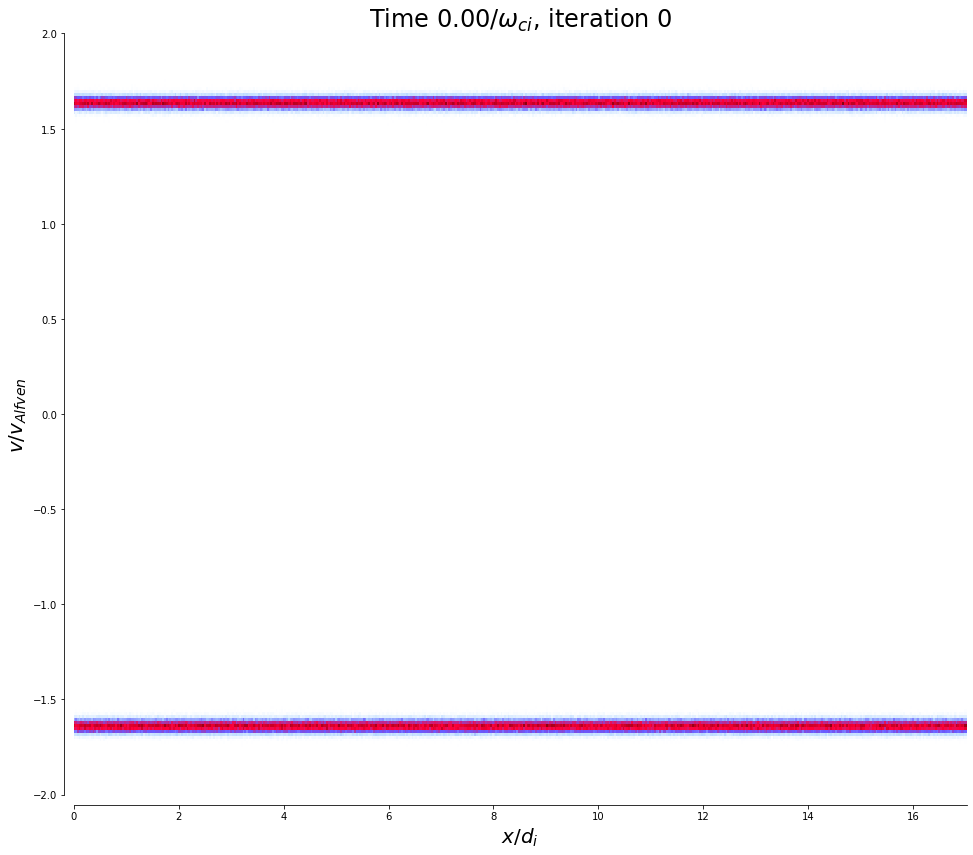

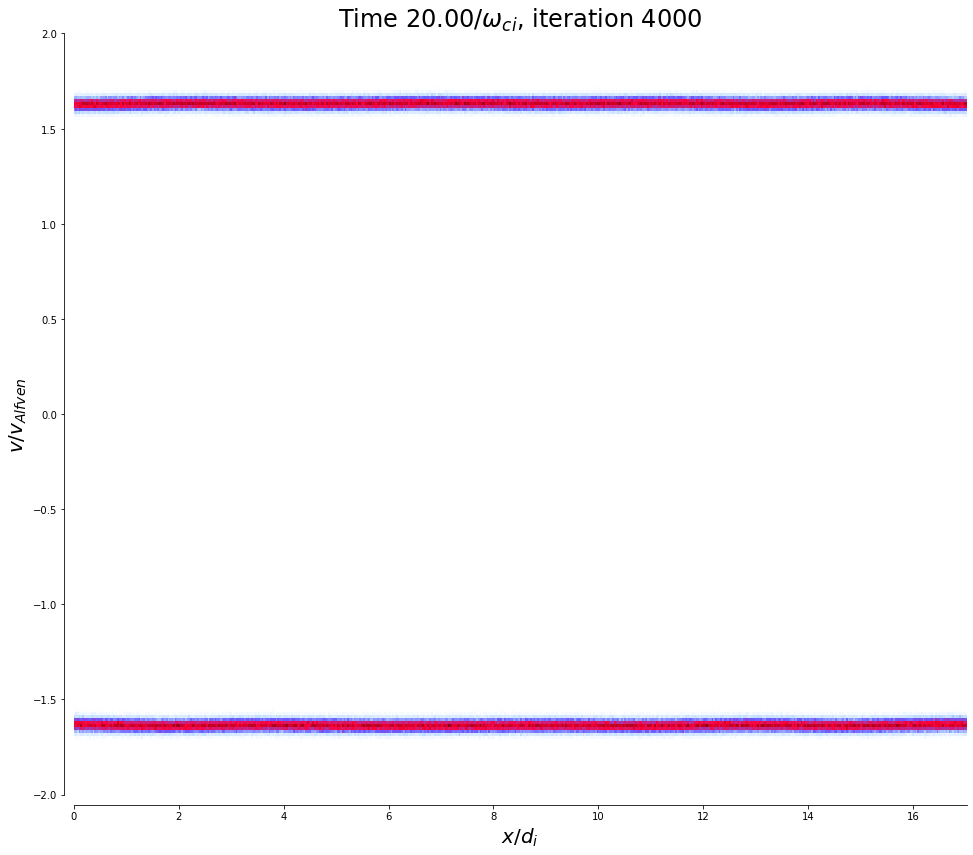

In [3]:
plt_phase_space(path+'/products', 0, mp, mg, v_max=2., res_x=512, res_v=256)
plt_phase_space(path+'/products', 4000, mp, mg, v_max=2., res_x=512, res_v=256)

In the plot of the electric field amplitude here below, we find an exponential growth during which the two beams stay mostly unpertubed.
We observe that the excited wave is constrained by the size of the simulation box. Changing slightly dx changes the wavelength. In this setup, we resolve 2 spatial periods of the wave, which gives us the $k$-vector amplitude of that wave. We use this $k$-vector as an input of the WHAMP solver, which provides us with a complex angular frequency $\omega$. The growth rate $\gamma = Im(\omega)$ is used in the plot below, and presents a perfect match with the growth of the simulated wave.

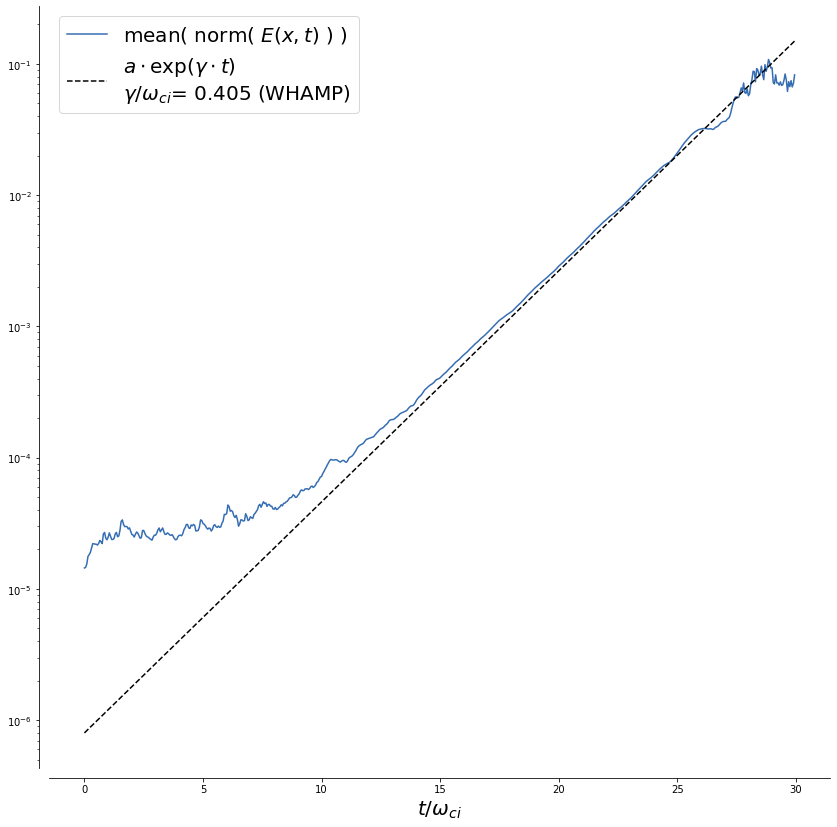

In [5]:
E_t_s = np.load(f'{path}/products/E_time_space_rank0.npy')
B_t_s = np.load(f'{path}/products/B_time_space_rank0.npy')
grid_t_low = np.arange(E_t_s.shape[1])*mp.dt_low

gamma = 0.4052865245366335
gamma = 0.4052865245366335
b = 9.5e-7
b = 8.e-7

e = np.sqrt(np.sum(E_t_s[:, :, :]**2, axis=(0)))/E_t_s.shape[2]

fig, ax = plt.subplots(figsize=(14, 14))

ax.plot(grid_t_low, np.mean(e, axis=1),
        oC.rgb[2], label='mean( norm( $E(x,t)$ ) )')
ax.plot(grid_t_low, np.exp(gamma*grid_t_low)*b,
        '--k', label='$a\cdot$exp($\gamma\cdot t$)\n$\gamma/\omega_{ci}$= '+f'{gamma:.3f} (WHAMP)')

ax.set_xlabel('$t/\omega_{ci}$', fontsize=20)
ax.set_yscale('log')
ax.legend(fontsize=20)

oT.set_spines(ax)
plt.savefig('wo_stream.pdf')
plt.show()

We see however in the time evolution of the electric field, taken at one node of the grid, that the mode excited by this setup presents electric and magnetic fields polarised along the stream direction, close to the ion cyclotron frequency as shown in the bottom spectra. It is because of the 3-dimensionality and the electromagnetic aspect of this wave that WHAMP was used instead of an electrostatic 1-dimensional Vlasov analytical approach.

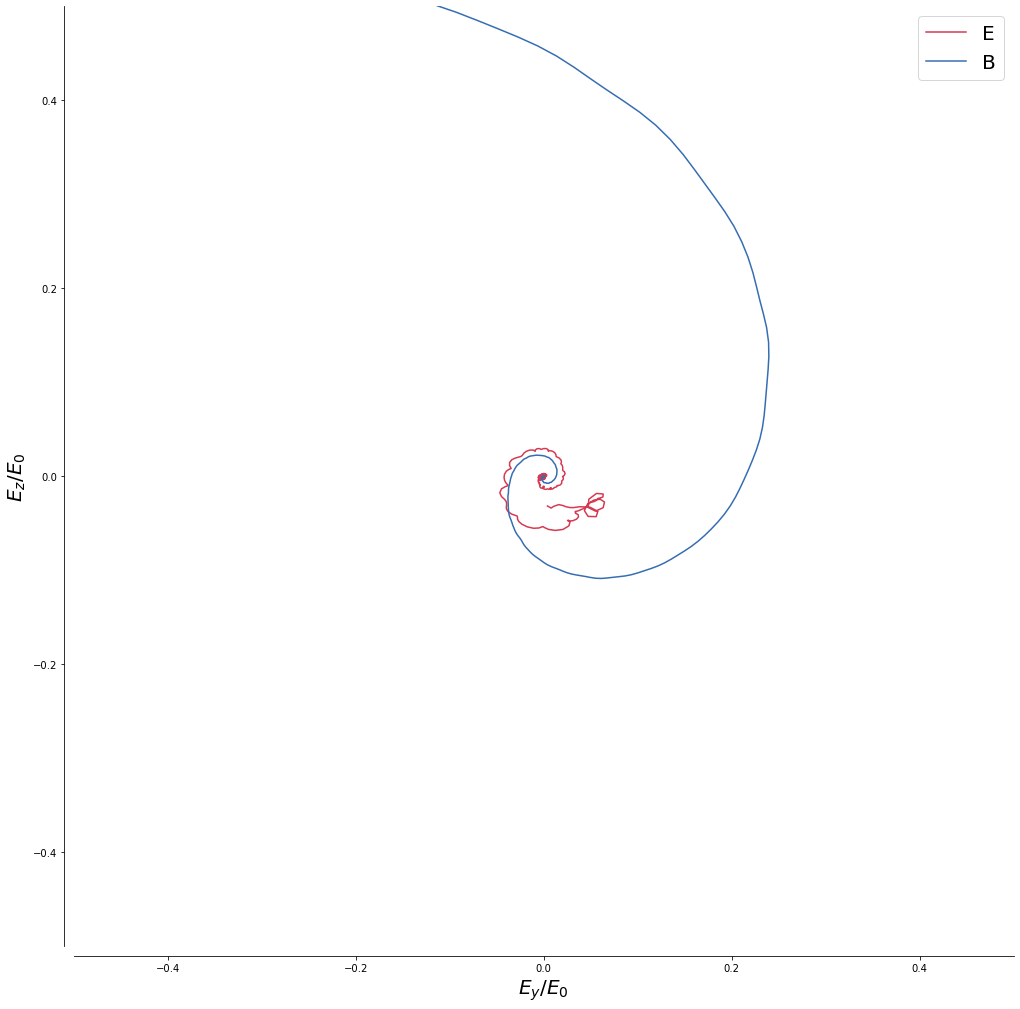

In [6]:
fig, ax = plt.subplots(figsize=(14, 14))
ax.set_aspect('equal')

ind_stop = 480
ax.plot(E_t_s[1, :ind_stop, 16], E_t_s[2, :ind_stop, 16], oC.rgb[0], label='E')
ax.plot(B_t_s[1, :ind_stop, 16], B_t_s[2, :ind_stop, 16], oC.rgb[2], label='B')

#ax.set_yscale('log')
#AX[0].set_xlabel('$t\cdot\omega_{ci}$', fontsize=20)
ax.set_xlabel('$E_{y}/E_0$', fontsize=20)
ax.set_ylabel('$E_{z}/E_0$', fontsize=20)
lim = .5
ax.set_ylim([-lim, lim])
ax.set_xlim([-lim, lim])
ax.legend(fontsize=20)

plt.tight_layout()
oT.set_spines(ax)
plt.show()

Two field components in $(x, t)$ and there Fourier transform are given below, with the WHAMP solution indicated by the white circle.

No handles with labels found to put in legend.


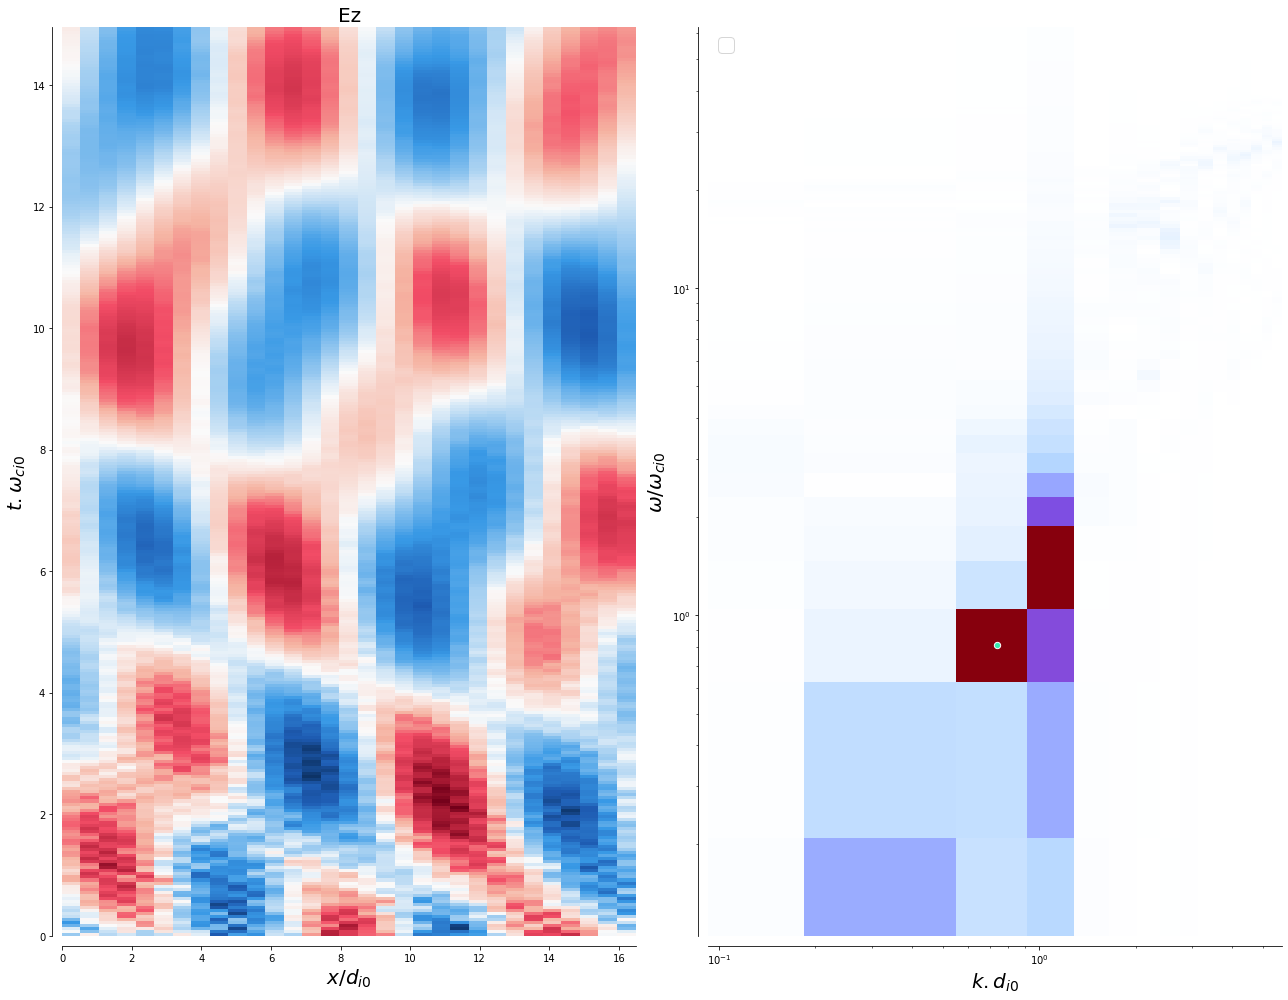

No handles with labels found to put in legend.


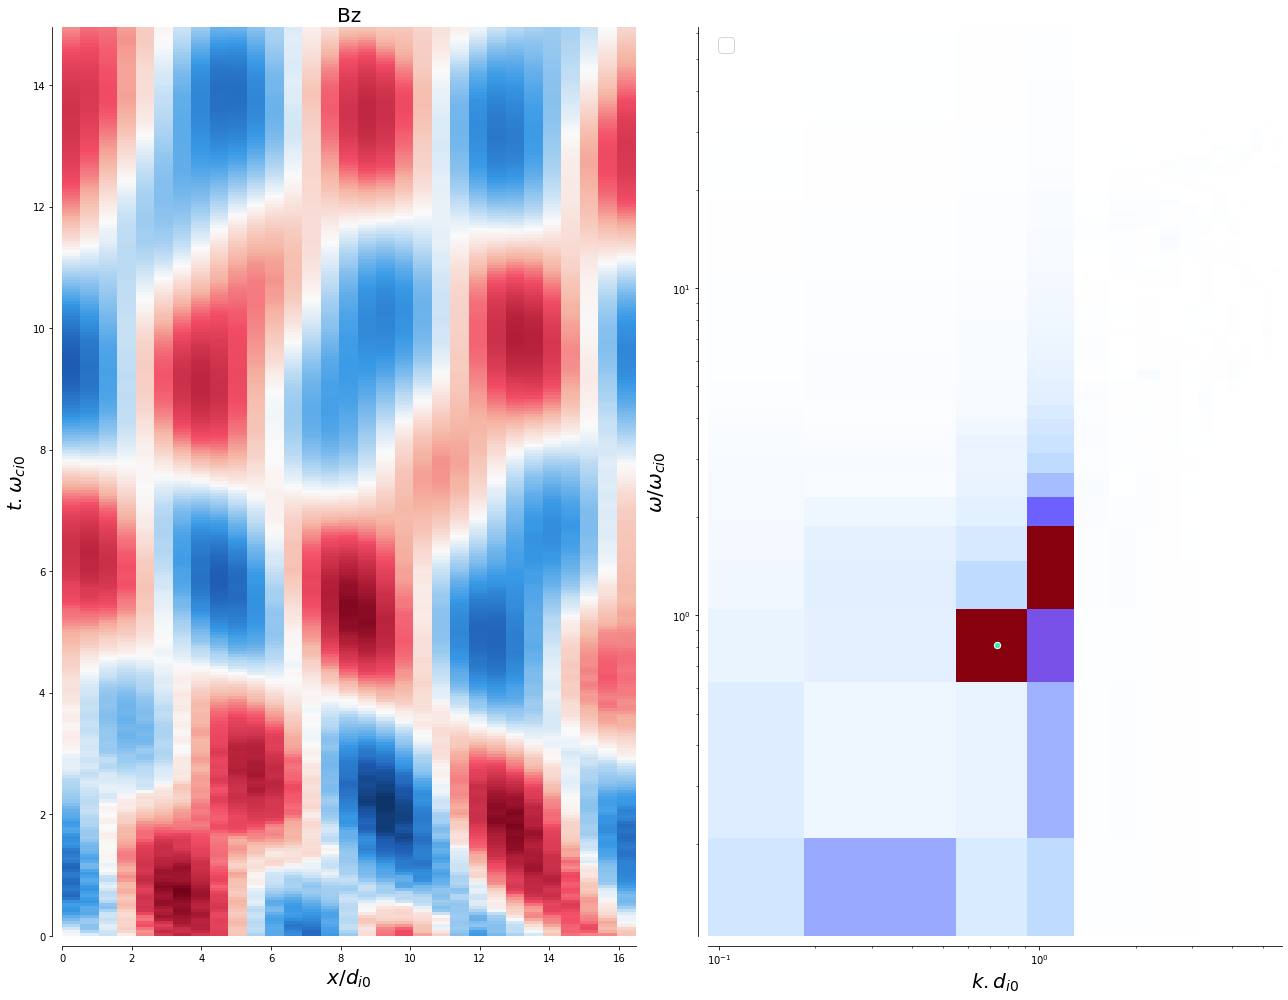

In [7]:
E_t_s    = np.load(f'{path}/products/E_time_space_rank0.npy')
B_t_s    = np.load(f'{path}/products/B_time_space_rank0.npy')

grid_t_low = np.arange(E_t_s.shape[1])*mp.dt_low


t_start = 200
t_stop = 500
ez = E_t_s[2, t_start:t_stop]
ez -= np.mean(ez)
ez *= np.exp(grid_t_low*-.405)[t_start:t_stop, None]
bz = B_t_s[2, t_start:t_stop]
bz -= np.mean(bz)
bz *= np.exp(grid_t_low*-.405)[t_start:t_stop, None]
    
field_omega_k_spectrum(ez, 'Ez', mp.dt_low, mp.dx_low, mp, loglog=True, disp_rel='two_stream')
field_omega_k_spectrum(bz, 'Bz', mp.dt_low, mp.dx_low, mp, loglog=True, disp_rel='two_stream')

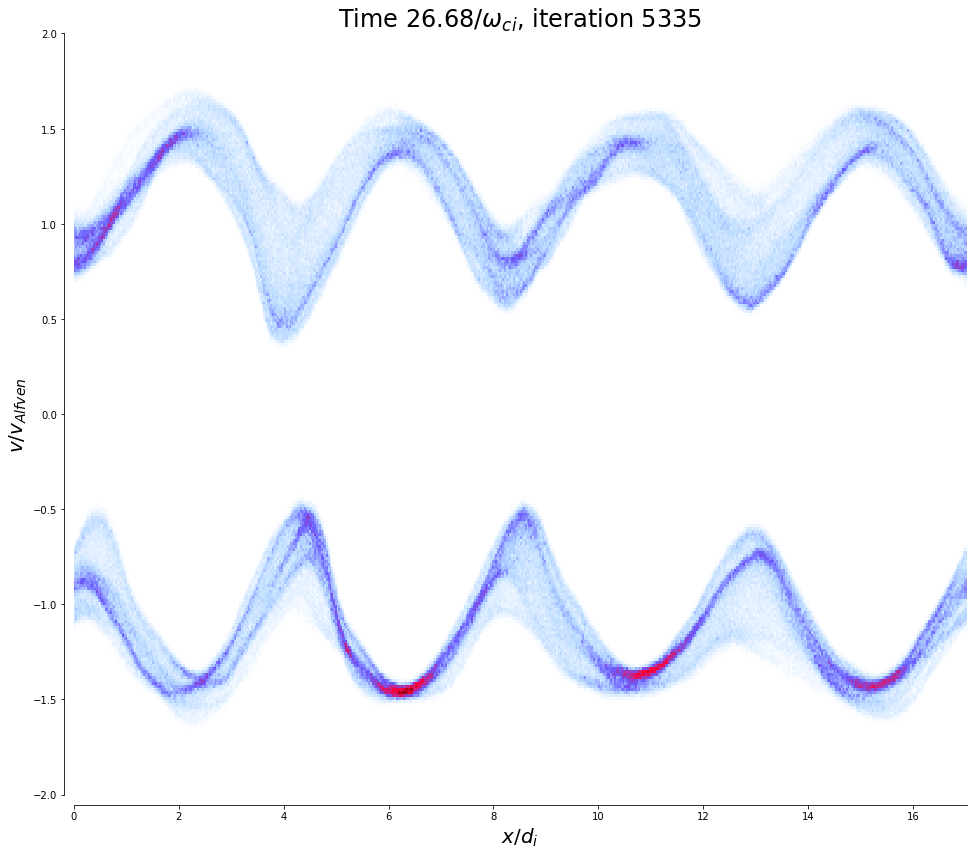

In [8]:
plt_phase_space(path+'/products', 5335, mp, mg, v_max=2., res_x=512, res_v=256)